In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2015-01-05,167.508804,-0.018225,NaN,NaN,0,0
2015-01-06,165.931046,-0.009464,NaN,NaN,0,0
2015-01-07,167.998779,0.012384,NaN,NaN,0,0
2015-01-08,170.979889,0.017589,NaN,NaN,0,0
2015-01-09,169.609756,-0.008046,NaN,NaN,0,0


In [4]:
df.tail()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320801,0.011054,1.432930,0.007806,0,1
2024-12-26,594.360352,0.000067,1.531647,0.007909,0,1
2024-12-27,588.103821,-0.010582,1.443915,0.007804,0,1
2024-12-30,581.392578,-0.011477,1.358178,0.007945,0,1
2024-12-31,579.277405,-0.003645,1.268185,0.008096,0,1


In [5]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

Ticker,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004128,1.616922,0.006485,0,1
2024-12-18,-0.030257,1.587696,0.006517,0,1
2024-12-19,-0.000307,1.356802,0.007658,0,1
2024-12-20,0.011939,1.310545,0.007650,0,1
2024-12-23,0.005970,1.326526,0.007780,0,1
2024-12-24,0.011054,1.432930,0.007806,0,1
2024-12-26,0.000067,1.531647,0.007909,0,1
2024-12-27,-0.010582,1.443915,0.007804,0,1
2024-12-30,-0.011477,1.358178,0.007945,0,1


In [6]:
df[['Vol State', 'Regime']].dropna().dtypes

Ticker
Vol State    int64
Regime       int64
dtype: object

In [7]:
df['Log Return'].std()

0.011136947865080698

In [8]:
df['T-Stat_200'].describe()

count    2315.000000
mean        0.922883
std         0.926916
min        -1.310081
25%         0.207416
50%         0.924992
75%         1.697499
max         3.438996
Name: T-Stat_200, dtype: float64

In [9]:
df['Volatility'].describe()

count    2455.000000
mean        0.009738
std         0.005574
min         0.003136
25%         0.006556
50%         0.008349
75%         0.011527
max         0.038925
Name: Volatility, dtype: float64

In [10]:
df.isna().sum()

Ticker
SPY             0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          0
dtype: int64

In [11]:
df['Regime'].value_counts(normalize = True)

Regime
 0    0.557455
 1    0.434592
-1    0.007952
Name: proportion, dtype: float64

In [12]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.769384
1    0.230616
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

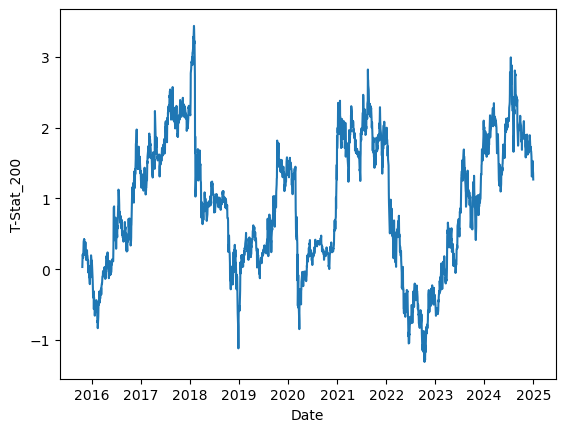

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

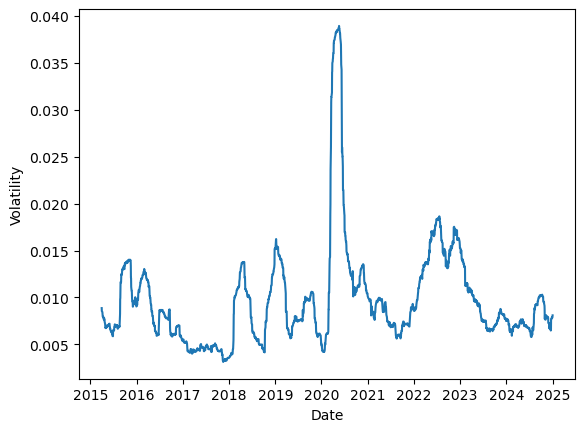

In [14]:
sns.lineplot(data = df['Volatility'])

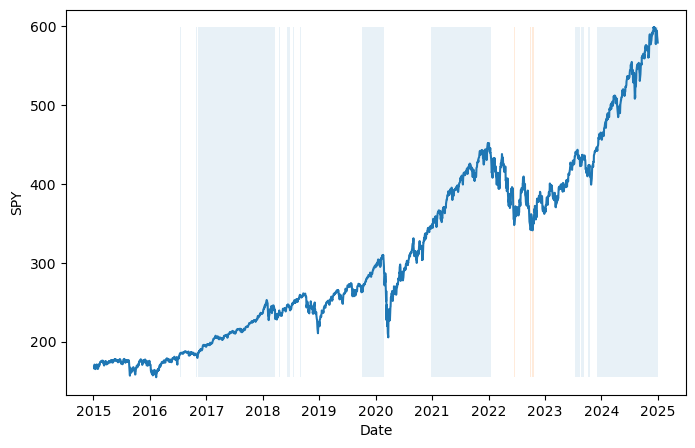

In [15]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['SPY'], ax = ax)
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [16]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0006101965796371301
0.0003268210976297291
0.005810385808208902


count    20.000000
mean      0.005810
std       0.017141
min      -0.023052
25%      -0.006543
50%       0.002917
75%       0.024224
max       0.030516
Name: Forward Return, dtype: float64

In [17]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1    0.017141
 0    0.013265
 1    0.007337
Name: Forward Return, dtype: float64

In [18]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

1.5159382898472933


In [19]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.748401740679903


In [20]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

0.9224889948113693


In [21]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.007760
1    0.016131
Name: Forward Vol, dtype: float64

In [22]:
from regime import markov

matrix = build_matrix(df)
print(matrix)

NameError: name 'build_matrix' is not defined